# Planteamiento de problema

Se va a analizar un dataset de bajas de servicios móviles para crear un modelo capaz de predecir futuras bajas del servicio.

In [1]:
# Your code here

import pandas as pd 
ruta = '/workspaces/ProyectoFinalDS_Churn_Pablo_Sahid/data/raw/Churn_Dataset.csv'

df = pd.read_csv(ruta)

df.head()

/tmp/ipykernel_1642/359360566.py:6: DtypeWarning: Columns (0: Churn) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


# Paso 1: Generar database SQLite y transformarlo a DataFrame


In [2]:
import sqlite3

# ruta de guardado y nombre de la base de datos
db_dir_name = "/workspaces/ProyectoFinalDS_Churn_Pablo_Sahid/data/raw/sahid_pablo_churn.db"

# crear o guardar base de datos 
con = sqlite3.connect(db_dir_name)
df.to_sql('usuarios', con, if_exists = 'replace', index = False)   #pasar df a tabla de sqlite
con.close() #cerrar conexion a la db

# crear un dataframe a partir de la tabla de la base de datos
conexion = sqlite3.connect(db_dir_name) #volver a conectar a la base de datos
consulta = "SELECT * FROM usuarios"  #consulta -> "pillar toda la tabla"
df2 = pd.read_sql_query(consulta, conexion) # la tabla es pasada a dataframe usando la consulta de antes
conexion.close()

df2.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


## Limpieza de datos preliminar:

- CustomerID: columnas de ID
- DroppedBlockedCalls: es la combinación de las columnas DroppedCalls y BlockedCalls
- NotNewCellphoneUser: NewCellphoneUser es su variable espejo por lo cual es innecesario tener ambas

In [3]:
df2= df2.drop(columns = ['CustomerID','DroppedBlockedCalls','NotNewCellphoneUser']) 
df2.shape

(71047, 55)

In [4]:
#Comprobación de duplicados
df2.duplicated().sum() #no hay duplicados, no hace falta limpiar filas 

np.int64(0)

# Paso 2: Estadística descriptiva

In [5]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 71047 entries, 0 to 71046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      51047 non-null  str    
 1   MonthlyRevenue             70831 non-null  float64
 2   MonthlyMinutes             70831 non-null  float64
 3   TotalRecurringCharge       70831 non-null  float64
 4   DirectorAssistedCalls      70831 non-null  float64
 5   OverageMinutes             70831 non-null  float64
 6   RoamingCalls               70831 non-null  float64
 7   PercChangeMinutes          70545 non-null  float64
 8   PercChangeRevenues         70545 non-null  float64
 9   DroppedCalls               71047 non-null  float64
 10  BlockedCalls               71047 non-null  float64
 11  UnansweredCalls            71047 non-null  float64
 12  CustomerCareCalls          71047 non-null  float64
 13  ThreewayCalls              71047 non-null  float64
 14  R

In [6]:
df2.describe()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,70831.000000,70831.000000,70831.000000,70831.000000,70831.000000,70831.000000,70545.000000,70545.000000,71047.000000,71047.000000,...,71046.000000,71046.000000,71046.000000,69803.000000,69803.000000,71047.000000,71047.000000,71047.000000,71047.000000,71047.000000
mean,58.852853,525.726250,46.862899,0.894817,40.087730,1.222315,-10.845304,-1.204730,6.009567,4.066459,...,1.808617,1.561791,380.265631,31.375113,21.157715,0.037004,0.017918,0.050854,4.334229,0.053162
std,44.243566,530.136184,23.915000,2.197577,96.349599,9.081089,255.314034,38.770236,9.006656,10.671180,...,1.336120,0.908280,254.294692,22.082195,23.917586,0.205823,0.141485,0.290444,3.137063,0.374988
min,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,0.000000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.640000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,0.000000,...,1.000000,1.000000,204.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,48.530000,366.000000,45.000000,0.250000,2.000000,0.000000,-5.000000,-0.300000,3.000000,1.000000,...,1.000000,1.000000,330.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,71.030000,722.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,3.700000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,1223.380000,7668.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,384.300000,...,28.000000,16.000000,1823.000000,99.000000,99.000000,4.000000,4.000000,35.000000,9.000000,25.000000


In [7]:
df2.mode().iloc[0] #moda de cada columna

Churn                               No
MonthlyRevenue                   29.99
MonthlyMinutes                     0.0
TotalRecurringCharge              30.0
DirectorAssistedCalls              0.0
OverageMinutes                     0.0
RoamingCalls                       0.0
PercChangeMinutes                  0.0
PercChangeRevenues                 0.0
DroppedCalls                       0.0
BlockedCalls                       0.0
UnansweredCalls                    0.0
CustomerCareCalls                  0.0
ThreewayCalls                      0.0
ReceivedCalls                      0.0
OutboundCalls                      0.0
InboundCalls                       0.0
PeakCallsInOut                     0.0
OffPeakCallsInOut                  0.0
CallForwardingCalls                0.0
CallWaitingCalls                   0.0
MonthsInService                     11
UniqueSubs                           1
ActiveSubs                           1
ServiceArea                  NYCBRO917
Handsets                 

In [8]:
#vamos a calcular el rango de cada columna numérica, por lo que el primer paso será hacer una selección de las columnas numéricas. 
df2_numeric = df2.select_dtypes(include=['float64', 'int64']) # Seleccionar columnas con datos numéricos (ints y floats).
df2_numeric.max() - df2_numeric.min() #rango de cada columna numérica


MonthlyRevenue               1229.55
MonthlyMinutes               7668.00
TotalRecurringCharge          411.00
DirectorAssistedCalls         159.39
OverageMinutes               4321.00
RoamingCalls                 1112.40
PercChangeMinutes            9067.00
PercChangeRevenues           3591.20
DroppedCalls                  221.70
BlockedCalls                  384.30
UnansweredCalls               848.70
CustomerCareCalls             365.70
ThreewayCalls                  66.00
ReceivedCalls                3287.20
OutboundCalls                 644.30
InboundCalls                  519.30
PeakCallsInOut               2090.70
OffPeakCallsInOut            1572.70
CallForwardingCalls            81.30
CallWaitingCalls              212.70
MonthsInService                55.00
UniqueSubs                    195.00
ActiveSubs                     53.00
Handsets                       27.00
HandsetModels                  15.00
CurrentEquipmentDays         1828.00
AgeHH1                         99.00
A

In [9]:
#mediana de cada columna numérica
df2_numeric.median() #mediana de cada columna numérica

MonthlyRevenue                48.53
MonthlyMinutes               366.00
TotalRecurringCharge          45.00
DirectorAssistedCalls          0.25
OverageMinutes                 2.00
RoamingCalls                   0.00
PercChangeMinutes             -5.00
PercChangeRevenues            -0.30
DroppedCalls                   3.00
BlockedCalls                   1.00
UnansweredCalls               16.30
CustomerCareCalls              0.00
ThreewayCalls                  0.00
ReceivedCalls                 52.50
OutboundCalls                 13.70
InboundCalls                   2.00
PeakCallsInOut                62.00
OffPeakCallsInOut             35.70
CallForwardingCalls            0.00
CallWaitingCalls               0.30
MonthsInService               16.00
UniqueSubs                     1.00
ActiveSubs                     1.00
Handsets                       1.00
HandsetModels                  1.00
CurrentEquipmentDays         330.00
AgeHH1                        36.00
AgeHH2                      

In [10]:
df2_numeric.var() #varianza de cada columna numérica

MonthlyRevenue                 1957.493124
MonthlyMinutes               281044.373966
TotalRecurringCharge            571.927229
DirectorAssistedCalls             4.829343
OverageMinutes                 9283.245191
RoamingCalls                     82.466177
PercChangeMinutes             65185.255823
PercChangeRevenues             1503.131165
DroppedCalls                     81.119852
BlockedCalls                    113.874080
UnansweredCalls                1513.530358
CustomerCareCalls                26.637621
ThreewayCalls                     1.350420
ReceivedCalls                 27657.533208
OutboundCalls                  1235.357172
InboundCalls                    272.895455
PeakCallsInOut                11007.151189
OffPeakCallsInOut              8710.306254
CallForwardingCalls               0.316128
CallWaitingCalls                 30.878139
MonthsInService                  95.796496
UniqueSubs                        1.280912
ActiveSubs                        0.435665
Handsets   

# Paso 3: Análisis de variables univariantes
#### Análisis sobre variables categóricas

VARIABLES CATEGORICAS:

De las 23 variables categóricas hemos decidido realizar el estudio  de las 14 siguientes:

- Churn: ademas es variable objetivo. Gente que se da de baja del servicio.
- HandsetWebCapable: Si el equipo puede navegar internet o no
- Homeownership: Si tiene vivienda o no
- BuysViaMailOrder: si compra por catalogo/correo
- RespondsToMailOffers: si responde a ofertas enviadas por correo
- OptOutMailings: si se ha dado de baja de la publicidad
- HasCreditCard: si tiene tarjeta de credito o no
- NewCellphoneUser: si es usuario nuevo o no
- MadeCallToRetentionTeam: si hubo llamada con el equipo de retencion 
- MaritalStatus: estado civil
- PrizmCode: si vive en pueblo, urbano, suburbano, area rural
- Occupation: ocupacion del cliente
- CreditRating: riesgo de impago. 1 es el valor de mayor riesgo y 7 el menor
- HandsetPrice: precio del equipo por rango

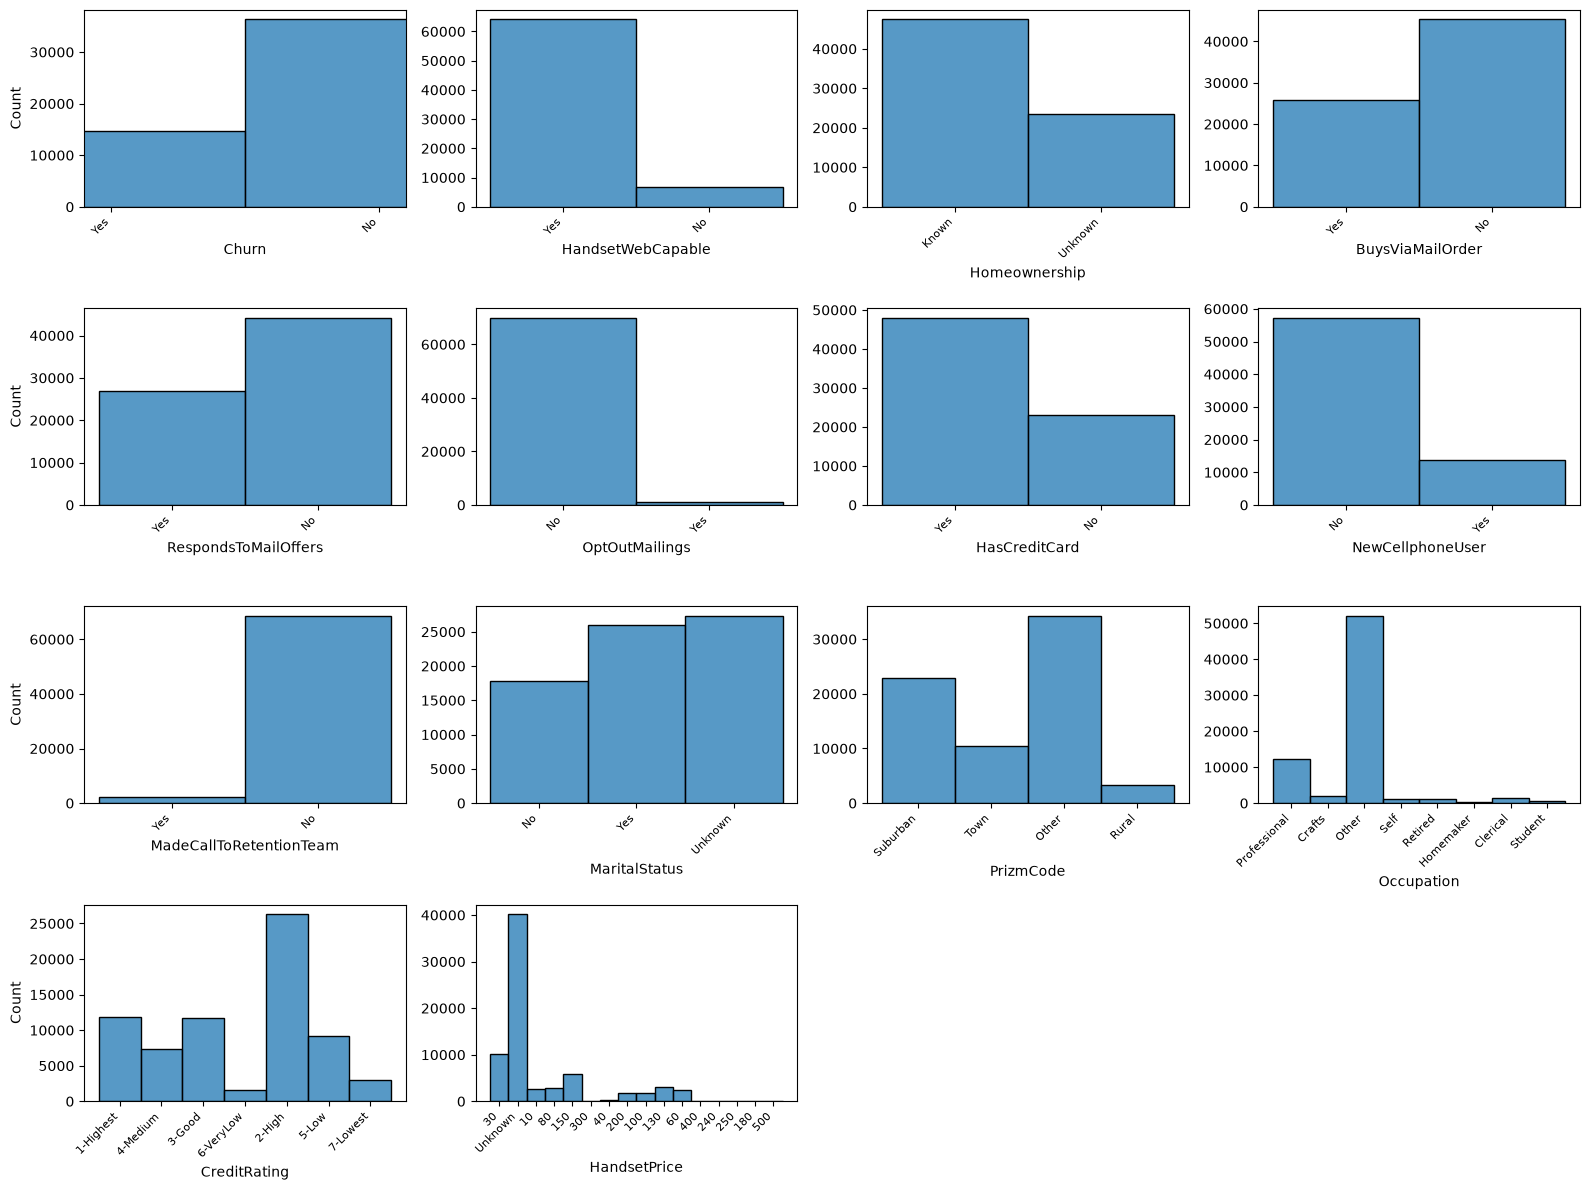

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(4, 4, figsize = (16, 12))

# Crear un histograma múltiple
sns.histplot(ax = axis[0, 0], data = df2, x = "Churn").set_xlim(-0.1, 1.1)
sns.histplot(ax = axis[0, 1], data = df2, x = "HandsetWebCapable").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = df2, x = "Homeownership").set(ylabel = None)
sns.histplot(ax = axis[0, 3], data = df2, x = "BuysViaMailOrder").set(ylabel = None)
sns.histplot(ax = axis[1, 0], data = df2, x = "RespondsToMailOffers")
sns.histplot(ax = axis[1, 1], data = df2, x = "OptOutMailings").set(ylabel = None)
sns.histplot(ax = axis[1, 2], data = df2, x = "HasCreditCard").set(ylabel = None)
sns.histplot(ax = axis[1, 3], data = df2, x = "NewCellphoneUser").set(ylabel = None)
sns.histplot(ax = axis[2, 0], data = df2, x = "MadeCallToRetentionTeam")
sns.histplot(ax = axis[2, 1], data = df2, x = "MaritalStatus").set(ylabel = None)
sns.histplot(ax = axis[2, 2], data = df2, x = "PrizmCode").set(ylabel = None)
sns.histplot(ax = axis[2, 3], data = df2, x = "Occupation").set(ylabel = None)
sns.histplot(ax = axis[3, 0], data = df2, x = "CreditRating")
sns.histplot(ax = axis[3, 1], data = df2, x = "HandsetPrice").set(ylabel = None)
sns.histplot(ax = axis[3, 2]).set_visible(False) # Ocultar el último subplot vacío
sns.histplot(ax = axis[3, 3]).set_visible(False) # Ocultar el último subplot vacío

# Rotar etiquetas del eje X en todos los subplots para evitar solapamientos de las etiquetas de los gráficos
for ax in axis.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    # Alinear texto
    plt.setp(ax.get_xticklabels(), ha='right')


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Churn: segun lo observado los clientes que No se dan de baja superan por mas del doble a los que si.
- HandsetWebCapable: hay minoría de clientes con dispositivos que no navegan en internet.
- Homeownership: no arroja información clara.
- BuysViaMailOrder: la mayoría de los clientes (2/3) no realizan compras por catalogos/correo.
- RespondsToMailOffers: los valores son similares a la categoría anterior.
- OptOutMailings: practicamente ningún cliente se ha dado de baja de recibir correspondencia publicitaria.
- HasCreditCard: la mayoría de clientes (2/3) poseen activas tarjetas de credito.
- NewCellphoneUser: alrededor de un 20% son nuevos usuarios de telefonía movil.
- MadeCallToRetentionTeam: muy pocos clientes han llamado al equipo de retención de la compañía.  
- MaritalStatus: no arroja información clara, aparentemente hay un porcentaje importante que no se sabe su situación marital.
- PrizmCode: de la mitad de los clientes no contamos con la información del tipo de zona donde reside, de la otra mitad sabemos que la mayoría se     encuentra ubicada en zonas suburbanas y el sobrante se reparte entre pueblo y rural.  
- Occupation: alrededor de 1000 clientes estan categorizados como profesionales, del resto la mayoría desconocemos su profesión
- CreditRating: la mitad de clientes tienen un alto riesgo de impago.
- HandsetPrice: de 40000 clientes no conocemos esta información (unknown), es decir no conocemos el precio de su equipo.






#### Análisis sobre variables numéricas

- MonthlyRevenue: Ingreso mensual generado por el cliente
- MonthlyMinutes: Minutos de uso mensual
- TotalRecurringCharge:	Cargo fijo recurrente mensual (cuota del plan)
- DirectorAssistedCalls: Cargos por llamadas asistidas por operadora
- OverageMinutes: Minutos consumidos por encima del plan contratado
- RoamingCalls:	Llamadas realizadas en roaming
- PercChangeMinutes: Variación porcentual de minutos respecto al periodo anterior
- PercChangeRevenues: Variación porcentual de ingresos respecto al periodo anterior
- DroppedCalls:	Llamadas caídas (cortadas)
- BlockedCalls: Llamadas bloqueadas (no se pudieron completar)
- CustomerCareCalls: Llamadas al servicio de atención al cliente
- ReceivedCalls: Llamadas recibidas
- OutboundCalls: Llamadas salientes
- InboundCalls:	Llamadas entrantes
- MonthsInService: Meses que el cliente lleva con la compañía (antigüedad)
- ActiveSubs: Número de líneas actualmente activas
- RetentionCalls: Número de llamadas al departamento de retención
- RetentionOffersAccepted: Número de ofertas de retención aceptadas
- IncomeGroup: Grupo/rango de ingresos del hogar (numérica pero funcionalmente ordinal)


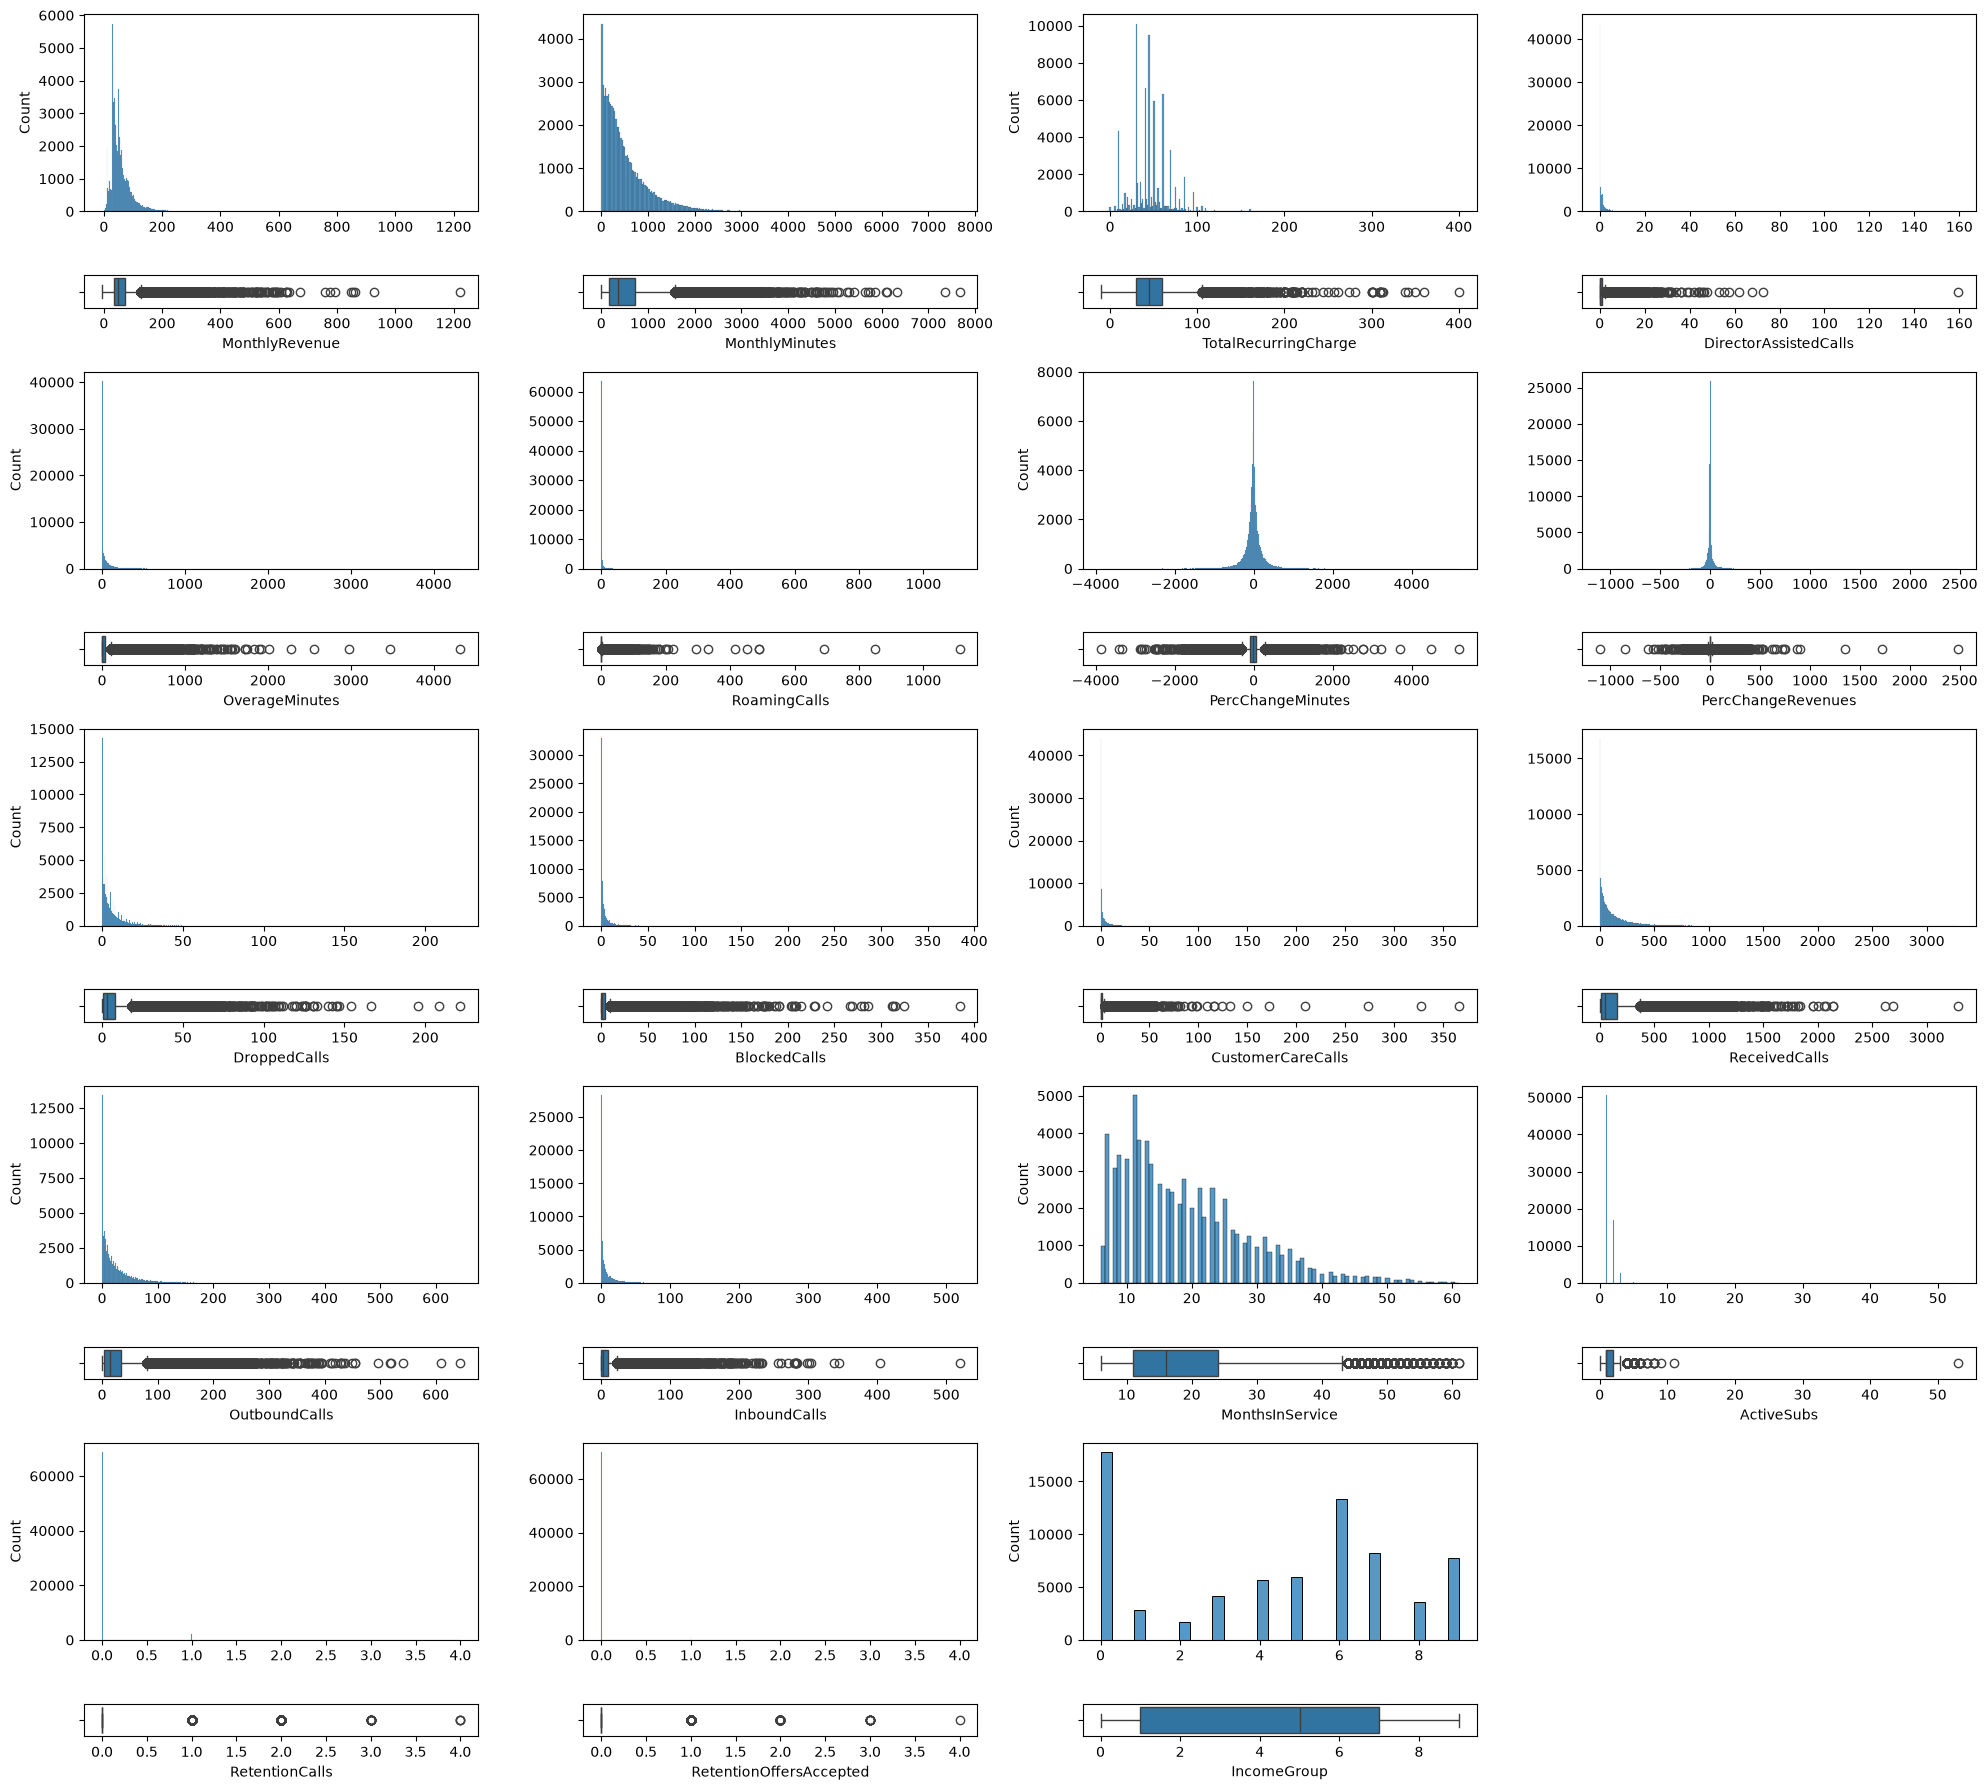

In [18]:
fig, axis = plt.subplots(10, 4, figsize = (20, 18), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1, 6, 1, 6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = df2, x = "MonthlyRevenue").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df2, x = "MonthlyRevenue")
sns.histplot(ax = axis[0, 1], data = df2, x = "MonthlyMinutes").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df2, x = "MonthlyMinutes")
sns.histplot(ax = axis[0, 2], data = df2, x = "TotalRecurringCharge").set(xlabel = None)
sns.boxplot(ax = axis[1, 2], data = df2, x = "TotalRecurringCharge")
sns.histplot(ax = axis[0, 3], data = df2, x = "DirectorAssistedCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 3], data = df2, x = "DirectorAssistedCalls")

sns.histplot(ax = axis[2, 0], data = df2, x = "OverageMinutes").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = df2, x = "OverageMinutes")
sns.histplot(ax = axis[2, 1], data = df2, x = "RoamingCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df2, x = "RoamingCalls")
sns.histplot(ax = axis[2, 2], data = df2, x = "PercChangeMinutes").set(xlabel = None)
sns.boxplot(ax = axis[3, 2], data = df2, x = "PercChangeMinutes")
sns.histplot(ax = axis[2, 3], data = df2, x = "PercChangeRevenues").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 3], data = df2, x = "PercChangeRevenues")

sns.histplot(ax = axis[4, 0], data = df2, x = "DroppedCalls").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = df2, x = "DroppedCalls")
sns.histplot(ax = axis[4, 1], data = df2, x = "BlockedCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = df2, x = "BlockedCalls")
sns.histplot(ax = axis[4, 2], data = df2, x = "CustomerCareCalls").set(xlabel = None)
sns.boxplot(ax = axis[5, 2], data = df2, x = "CustomerCareCalls")
sns.histplot(ax = axis[4, 3], data = df2, x = "ReceivedCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 3], data = df2, x = "ReceivedCalls")

sns.histplot(ax = axis[6, 0], data = df2, x = "OutboundCalls").set(xlabel = None)
sns.boxplot(ax = axis[7, 0], data = df2, x = "OutboundCalls")
sns.histplot(ax = axis[6, 1], data = df2, x = "InboundCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 1], data = df2, x = "InboundCalls")
sns.histplot(ax = axis[6, 2], data = df2, x = "MonthsInService").set(xlabel = None)
sns.boxplot(ax = axis[7, 2], data = df2, x = "MonthsInService")
sns.histplot(ax = axis[6, 3], data = df2, x = "ActiveSubs").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 3], data = df2, x = "ActiveSubs")

sns.histplot(ax = axis[8, 0], data = df2, x = "RetentionCalls").set(xlabel = None)
sns.boxplot(ax = axis[9, 0], data = df2, x = "RetentionCalls")
sns.histplot(ax = axis[8, 1], data = df2, x = "RetentionOffersAccepted").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[9, 1], data = df2, x = "RetentionOffersAccepted")
sns.histplot(ax = axis[8, 2], data = df2, x = "IncomeGroup").set(xlabel = None)
sns.boxplot(ax = axis[9, 2], data = df2, x = "IncomeGroup")
axis[8, 3].set_visible(False) # Ocultar el último subplot vacío
axis[9, 3].set_visible(False)



# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()